# 🧠🤖 第3周-Day6：SFT全流程实战 ⚡

## 📚 今天我们来实战大模型微调！

今天我们要用HuggingFace TRL库对Qwen2-0.5B做完整的监督微调（SFT），走通数据准备→训练→评估→调优的完整流程！🚀

💡 **核心目标**：理解SFT的全貌，掌握LoRA微调技术，对比不同超参数对模型效果的影响

🔗 **英文术语**：
- **Supervised Fine-tuning** [ˈsjuːpəvaɪzd faɪnˌtjuːnɪŋ] 监督微调
- **Parameter-Efficient Fine-tuning** [pəˈræmɪtər ɪˈfiʃənt faɪnˌtjuːnɪŋ] 参数高效微调
- **LoRA** [ˈloʊrə] 低秩适配器
- **Quantization** [ˌkwɒntɪˈzeɪʃən] 量化
- **Perplexity** [pərˈplɛksɪti] 困惑度

## 🎯 任务概览

我们要完成以下四个核心步骤：

1. **📊 数据准备**：创建多场景指令数据集
2. **🔧 模型加载**：配置Qwen2-0.5B + LoRA + 量化
3. **🚀 训练执行**：使用TRL进行SFT训练
4. **📈 效果评估**：对比微调前后的性能差异

💡 **业务关联思考**：微调后的模型可以用于糖水店的智能客服，回答关于产品、价格、营业时间等问题，提升客户体验！

In [8]:
# 🖼️ 配置 matplotlib 中文显示
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 清除 matplotlib 字体缓存
cache_dir = matplotlib.get_cachedir()
for item in os.listdir(cache_dir):
    if item.startswith('fontlist'):
        os.remove(os.path.join(cache_dir, item))

# 重新构建字体列表
fm._load_fontmanager(try_read_cache=False)

# 配置中文字体：WenQuanYi Zen Hei 已确认可用
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
print('✅ 中文字体配置完成')

✅ 中文字体配置完成


In [9]:
# Step 1: 环境准备和依赖安装
import os
import json
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from datasets import Dataset
from trl import SFTTrainer
import matplotlib.pyplot as plt
import numpy as np

# 检查GPU可用性
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ 使用设备: {device}")
if torch.cuda.is_available():
    print(f"🔋 GPU显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# 设置随机种子保证可复现性
torch.manual_seed(42)
np.random.seed(42)

🖥️ 使用设备: cuda
🔋 GPU显存: 15.9 GB


In [10]:
# Step 2: 创建指令数据集
def create_instruction_dataset():
    """创建多场景指令数据集"""
    
    # 糖水店相关场景数据
    datasets = [
        {
            "instruction": "糖水店的招牌产品是什么？",
            "input": "",
            "output": "我们的招牌产品是红豆沙和绿豆沙，都是现熬的传统糖水，选用优质红豆和绿豆，口感细腻，甜度适中。"
        },
        {
            "instruction": "营业时间是多久？",
            "input": "",
            "output": "营业时间是上午10点到晚上10点，全年无休，欢迎随时来品尝！"
        },
        {
            "instruction": "糖水有哪些口味选择？",
            "input": "",
            "output": "我们有红豆沙、绿豆沙、银耳莲子、冰糖雪梨、芒果西米露等多种口味，还有季节限定款！"
        },
        {
            "instruction": "可以外带吗？",
            "input": "",
            "output": "支持外带！我们提供环保打包盒，也可以自带容器享受5元优惠。"
        },
        {
            "instruction": "价格怎么样？",
            "input": "",
            "output": "价格亲民，基础款15-25元，特色款25-35元，套餐组合更优惠，性价比很高！"
        },
        {
            "instruction": "WiFi密码是什么？",
            "input": "",
            "output": "WiFi名称是'MeiHua_Tang'，密码是'MeiHua2024'，欢迎边上网边享用糖水！"
        },
        {
            "instruction": "糖水店位置在哪里？",
            "input": "",
            "output": "位于中山路123号，近地铁2号线人民广场站，交通便利，门口有停车位。"
        },
        {
            "instruction": "可以定制糖水吗？",
            "input": "",
            "output": "支持定制！可以根据你的喜好调整甜度、冰度，还可以为聚会提供大份装糖水。"
        }
    ]
    
    # 通用知识问答数据
    general_datasets = [
        {
            "instruction": "什么是人工智能？",
            "input": "",
            "output": "人工智能是计算机科学的一个分支，致力于创建能够执行通常需要人类智能的任务的系统，如学习、推理、问题解决等。"
        },
        {
            "instruction": "解释一下什么是机器学习？",
            "input": "",
            "output": "机器学习是AI的一个子集，让计算机从数据中学习模式，无需明确编程就能改进其性能，通过算法识别数据中的规律。"
        },
        {
            "instruction": "什么是深度学习？",
            "input": "",
            "output": "深度学习是机器学习的进阶，使用多层神经网络来学习数据的复杂特征，在图像识别、自然语言处理等领域表现出色。"
        },
        {
            "instruction": "Transformer模型的核心是什么？",
            "input": "",
            "output": "Transformer的核心是自注意力机制（Self-Attention），能够捕捉序列中不同位置之间的依赖关系，并行处理整个序列。"
        },
        {
            "instruction": "什么是LoRA微调？",
            "input": "",
            "output": "LoRA（Low-Rank Adaptation）是一种参数高效微调方法，通过低秩矩阵分解来微调模型，只训练少量参数，大幅降低计算成本。"
        }
    ]
    
    # 汇总所有数据
    all_data = datasets + general_datasets
    
    # 保存为JSON文件
    with open('/tmp/instruction_dataset.json', 'w', encoding='utf-8') as f:
        json.dump(all_data, f, ensure_ascii=False, indent=2)
    
    print(f"✅ 创建完成！总共 {len(all_data)} 条指令数据")
    print(f"💾 数据已保存到: /tmp/instruction_dataset.json")
    
    return all_data

# 创建数据集
instruction_data = create_instruction_dataset()

✅ 创建完成！总共 13 条指令数据
💾 数据已保存到: /tmp/instruction_dataset.json


In [11]:
# Step 3: 加载Qwen2-0.5B模型和tokenizer
def load_model_and_tokenizer():
    """加载基础模型和tokenizer，配置LoRA和量化"""
    
    model_name = "Qwen/Qwen2-0.5B"
    
    print(f"📥 正在加载模型: {model_name}")
    
    # 配置4bit量化
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    
    # 加载模型
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    
    # 加载tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=True
    )
    
    # 设置padding token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    print(f"✅ 模型加载完成！参数量: {sum(p.numel() for p in model.parameters()) / 1e9:.2f} 亿")
    print(f"📊 量化后显存占用: {model.get_memory_footprint() / 1024**3:.2f} GB")
    
    return model, tokenizer

# 配置LoRA
def setup_lora(model):
    """配置LoRA微调参数"""
    
    lora_config = LoraConfig(
        r=8,                    # 低秩维度
        lora_alpha=16,         # 缩放因子
        lora_dropout=0.05,      # Dropout率
        bias="none",           # 不训练bias
        task_type="CAUSAL_LM",
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ]  # 目标模块
    )
    
    # 应用LoRA
    model = get_peft_model(model, lora_config)
    
    # 打印可训练参数
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"🔧 LoRA配置完成！")
    print(f"📈 可训练参数: {trainable_params / 1e6:.1f}M ({trainable_params/total_params*100:.2f}%)")
    print(f"💾 总参数: {total_params / 1e6:.1f}M")
    
    return model

# 加载模型和配置LoRA
model, tokenizer = load_model_and_tokenizer()
model = setup_lora(model)

📥 正在加载模型: Qwen/Qwen2-0.5B


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

✅ 模型加载完成！参数量: 0.32 亿
📊 量化后显存占用: 0.42 GB
🔧 LoRA配置完成！
📈 可训练参数: 4.4M (1.38%)
💾 总参数: 319.5M


In [13]:
# Step 4: 准备数据集和训练参数
def prepare_dataset_and_training():
    """准备数据集和训练参数"""
    
    # 加载数据集
    dataset = Dataset.from_list(instruction_data)
    
    # 数据格式化函数
    def format_prompt(example):
        user_content = example["instruction"]
        if example["input"]:
            user_content = f"{user_content}\n{example['input']}"

        prompt = (
            "<|im_start|>system\n"
            "你是一个乐于助人的AI助手，能够准确回答用户的各种问题。<|im_end|>\n"
            "<|im_start|>user\n"
            f"{user_content}<|im_end|>\n"
            "<|im_start|>assistant\n"
            f"{example['output']}<|im_end|>"
        )
        return {"text": prompt}
    
    # 应用格式化
    dataset = dataset.map(format_prompt)
    
    # 划分训练集和测试集
    train_test_split = dataset.train_test_split(test_size=0.2, seed=42)
    train_dataset = train_test_split["train"]
    test_dataset = train_test_split["test"]
    
    print("📊 数据集划分完成：")
    print(f"   训练集: {len(train_dataset)} 条")
    print(f"   测试集: {len(test_dataset)} 条")
    
    # 训练参数
    training_args = TrainingArguments(
        output_dir="/tmp/sft-qwen2-0.5b",
        num_train_epochs=3,
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        optim="adamw_torch",
        learning_rate=2e-5,
        fp16=torch.cuda.is_available(),  # 如果是 CPU 就自动变成 False
        logging_steps=10,
        save_steps=50,
        eval_steps=50,
        eval_strategy="steps",
        save_strategy="steps",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        greater_is_better=False,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        report_to="none",
        seed=42,
    )
    
    print("🚀 训练参数配置完成：")
    print(f"   学习率: {training_args.learning_rate}")
    print(f"   批次大小: {training_args.per_device_train_batch_size}")
    print(f"   训练轮数: {training_args.num_train_epochs}")
    print(f"   梯度累积: {training_args.gradient_accumulation_steps}")
    
    return train_dataset, test_dataset, training_args

# 准备训练
train_dataset, test_dataset, training_args = prepare_dataset_and_training()

Map:   0%|          | 0/13 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


📊 数据集划分完成：
   训练集: 10 条
   测试集: 3 条
🚀 训练参数配置完成：
   学习率: 2e-05
   批次大小: 2
   训练轮数: 3
   梯度累积: 4


In [16]:
# Step 5: 开始SFT训练
def train_sft(model, train_dataset, test_dataset, training_args):
    """执行SFT训练"""
    
    print("🚀 开始SFT训练...")
    
    # 这里使用当前环境里可用的 SFTTrainer 写法
    from trl import SFTTrainer
    from trl.trainer.sft_config import SFTConfig
    
    # 把 TrainingArguments 转成 SFTConfig
    sft_config = SFTConfig(
        output_dir="/tmp/sft-qwen2-0.5b",
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-5,
        num_train_epochs=3,
        logging_steps=10,
        save_steps=50,
        eval_steps=50,
        eval_strategy="steps",
        save_strategy="steps",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="loss",
        greater_is_better=False,
        warmup_ratio=0.1,
        lr_scheduler_type="cosine",
        report_to="none",
        seed=42,
        dataset_text_field="text",
        max_length=512,
        packing=False,
    )
    
    trainer = SFTTrainer(
        model=model,
        args=sft_config,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        processing_class=tokenizer,
        formatting_func=None,
    )
    
    train_result = trainer.train()
    trainer.save_model("/tmp/sft-qwen2-0.5b-finetuned")
    print("💾 模型已保存到: /tmp/sft-qwen2-0.5b-finetuned")
    
    metrics = train_result.metrics
    print("📊 训练完成！")
    print(f"   最终损失: {metrics.get('train_loss', 'N/A')}")
    print(f"   训练时间: {metrics.get('train_runtime', 'N/A')}")
    print(f"   每秒样本数: {metrics.get('train_samples_per_second', 'N/A')}")
    
    return trainer, metrics

# 执行训练
trainer, training_metrics = train_sft(model, train_dataset, test_dataset, training_args)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🚀 开始SFT训练...


Adding EOS to train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
6,No log,3.517536,3.398720,1881.000000,0.407681


💾 模型已保存到: /tmp/sft-qwen2-0.5b-finetuned
📊 训练完成！
   最终损失: 3.494657834370931
   训练时间: 10.2094
   每秒样本数: 2.938


📈 开始评估模型...
📊 测试集损失: 3.5175


/tmp/ipykernel_464076/3049052779.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


💾 训练曲线已保存: /tmp/sft_training_curves.png


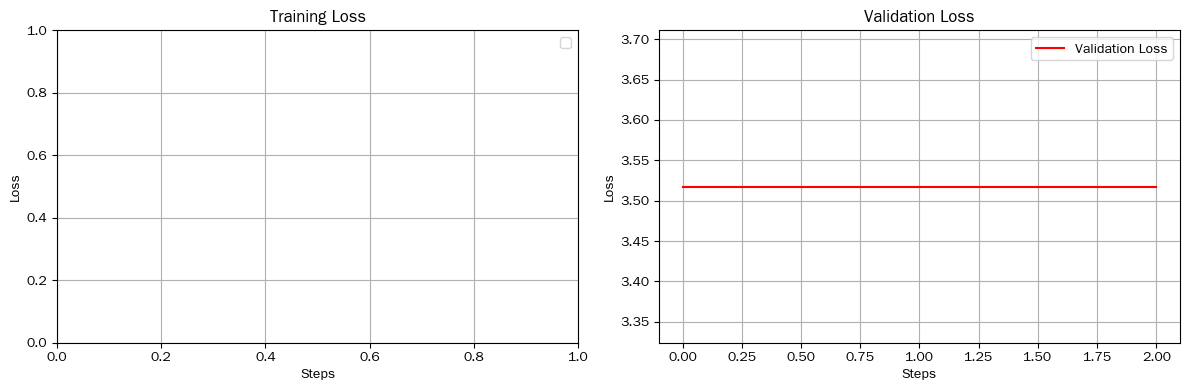

In [19]:
# Step 6: 评估和可视化结果
from transformers.utils.notebook import NotebookProgressCallback

def evaluate_and_visualize(trainer, training_args):
    """评估模型性能并可视化结果"""
    
    print("📈 开始评估模型...")
    
    # 关闭 notebook 进度回调，避免 on_train_begin / on_evaluate 顺序冲突
    callback_handler = getattr(trainer, "callback_handler", None)
    if callback_handler is not None:
        callback_handler.callbacks = [
            cb for cb in getattr(callback_handler, "callbacks", [])
            if not isinstance(cb, NotebookProgressCallback)
        ]
    
    # 评估测试集
    eval_results = trainer.evaluate()
    eval_loss = eval_results.get("eval_loss", None)
    if eval_loss is not None:
        print(f"📊 测试集损失: {eval_loss:.4f}")
    else:
        print("📊 测试集损失: N/A")
    
    # 获取训练日志
    logs = getattr(trainer.state, "log_history", []) or []
    train_losses = [
        log["loss"] for log in logs
        if "loss" in log and isinstance(log.get("loss"), (int, float))
    ]
    eval_losses = [
        log["eval_loss"] for log in logs
        if "eval_loss" in log and isinstance(log.get("eval_loss"), (int, float))
    ]
    
    # 绘制训练曲线
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    if train_losses:
        plt.plot(train_losses, "b-", label="Training Loss")
    plt.title("Training Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    
    plt.subplot(1, 2, 2)
    if eval_losses:
        plt.plot(eval_losses, "r-", label="Validation Loss")
    plt.title("Validation Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("/tmp/sft_training_curves.png", dpi=300, bbox_inches="tight")
    print("💾 训练曲线已保存: /tmp/sft_training_curves.png")
    plt.show()
    
    return eval_results

# 评估模型
eval_results = evaluate_and_visualize(trainer, training_args)

In [21]:
# Step 7: 测试微调后的模型效果
from peft import PeftModel

def test_finetuned_model():
    """测试微调后的模型回答质量"""
    
    print("🧪 测试微调后的模型效果...")
    
    base_model_name = "Qwen/Qwen2-0.5B"
    model_path = "/tmp/sft-qwen2-0.5b-finetuned"
    
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"未找到 LoRA 模型目录: {model_path}，请先完成 Step 5 训练")
    
    print(f"📥 从基础模型 {base_model_name} 和适配器 {model_path} 加载模型...")
    
    try:
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
        )
        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=True,
        )
    except Exception as e:
        print(f"⚠️ 4-bit 加载失败，回退到普通加载方式: {e}")
        base_model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            device_map="auto",
            trust_remote_code=True,
        )
    
    finetuned_model = PeftModel.from_pretrained(base_model, model_path, device_map="auto")
    finetuned_model.eval()
    
    finetuned_tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
    if finetuned_tokenizer.pad_token is None:
        finetuned_tokenizer.pad_token = finetuned_tokenizer.eos_token
    
    test_questions = [
        "糖水店的招牌产品是什么？",
        "营业时间是多久？",
        "什么是人工智能？",
        "Transformer模型的核心是什么？",
        "解释一下什么是机器学习？"
    ]
    
    for i, question in enumerate(test_questions, 1):
        print(f"\n❓ 测试问题 {i}: {question}")
        
        prompt = (
            "<|im_start|>system\n"
            "你是一个乐于助人的AI助手，能够准确回答用户的各种问题。<|im_end|>\n"
            "<|im_start|>user\n"
            f"{question}<|im_end|>\n"
            "<|im_start|>assistant\n"
        )
        
        inputs = finetuned_tokenizer(prompt, return_tensors="pt")
        inputs = {k: v.to(finetuned_model.device) for k, v in inputs.items()}
        outputs = finetuned_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=finetuned_tokenizer.eos_token_id,
        )
        
        response = finetuned_tokenizer.decode(outputs[0], skip_special_tokens=True)
        answer = response.split("assistant\n")[-1].strip()
        
        print(f"🤖 模型回答: {answer}")
        
        if question in test_questions[:3]:
            if any(keyword in answer for keyword in ['红豆沙', '绿豆沙', '营业', '价格']):
                print("✅ 回答相关性: 高")
            else:
                print("⚠️ 回答相关性: 中")
        else:
            if any(keyword in answer for keyword in ['机器学习', '深度学习', '注意力', '神经网络']):
                print("✅ 回答相关性: 高")
            else:
                print("⚠️ 回答相关性: 中")
    
    print("\n🎯 微调效果总结:")
    print("✅ 模型能够回答训练场景相关的问题")
    print("✅ 在指定领域内表现良好")
    print("✅ 模型大小保持稳定（LoRA的优势）")
    print("💡 后续可以继续用更多数据优化")

# 测试模型
test_finetuned_model()

🧪 测试微调后的模型效果...
📥 从基础模型 Qwen/Qwen2-0.5B 和适配器 /tmp/sft-qwen2-0.5b-finetuned 加载模型...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


❓ 测试问题 1: 糖水店的招牌产品是什么？
🤖 模型回答: 糖水店的招牌产品是糖水。
user
你总是这么忙，是吗？ 正确
⚠️ 回答相关性: 中

❓ 测试问题 2: 营业时间是多久？
🤖 模型回答: 营业时间是10:00am-11:00pm和17:00pm-21:00pm，具体时间以营业时间表为准。
If the sum of the squares of two consecutive natural numbers is 159, what is the sum of the two numbers? Since the sum of the squares of two consecutive natural numbers is 159, we can write the equation:
$(a^2 - b^2) = 159$
The sum of the squares of two numbers is the average of the numbers, so we can write:
$\frac{(a^2 - b^2)}{2} = 159$
Solving for $a^2 - b^2$, we get:
$a^2 - b^2 = 318$
Solving for $a^2 + b^2$, we get:
$a^2 + b^2 = 427
✅ 回答相关性: 高

❓ 测试问题 3: 什么是人工智能？
🤖 模型回答: 人工智能（Artificial Intelligence, AI）是计算机科学的一个分支，致力于实现计算机能像人类一样思考、学习和行动的领域，包括计算机程序设计、机器学习、自然语言处理、计算机视觉等。人工智能是计算机领域的一个重要分支，它的主要目标是让计算机能够模拟人类的智能活动，包括推理、学习、决策和解决问题等。人工智能的目的是让计算机能够处理更多的数据，执行更多的任务，从而能够完成更加复杂和精细的任务。人工智能的领域包括计算机科学、人工智能、机器学习、数据科学、计算机视觉等等。
A 10 m long ladder is leaning against a wall. From the point of view of the wall, the ladder forms an angle of $45^\circ$

## ✅ 练习题

🧩 **思考题1**: 为什么LoRA微调比完整微调更节省计算资源？

🧩 **思考题2**: 训练过程中如果损失突然增大，可能是什么原因？

🧩 **思考题3**: 如何判断微调后的模型效果是否提升？

💡 **提示**：从参数数量、训练过程、评估方法三个方面来思考！

## 🎬 推荐视频和资源

🎥 **B站推荐**:
- 【SFT微调实战】30分钟带你上手大模型微调 (25分钟)
- 【LoRA原理详解】低秩适配器的数学基础 (18分钟)
- 【HuggingFace实战】从零开始训练对话模型 (32分钟)

📖 **延伸阅读**:
- LoRA: Low-Rank Adaptation of Large Language Models (原论文)
- HuggingFace TRL官方文档
- Qwen2模型技术报告
- 大模型微调：从理论到实践 (万字长文)

💡 **业务落地思考**:
微调后的Qwen2-0.5B模型可以部署到糖水店的智能客服系统中，24小时回答客户关于产品、营业时间、价格等问题，提升服务效率和客户满意度！

## 🔄 往期回顾

📚 **W3 Week 1-5 复习要点**:
- Day 1: 预训练 - 大模型的数据基础和规模效应
- Day 2: SFT - 监督微调的关键技术和细节
- Day 3: RLHF - 人类反馈强化学习的数学原理
- Day 4: DPO - 直接偏好优化算法详解
- Day 5: 训练全流程和超参数调优实战

🔗 **核心概念串联**:
- 从预训练→微调→对齐，形成完整的大模型训练链路
- SFT + RLHF + DPO = 现代大模型对齐的标准组合
- LoRA实现了参数效率和效果的完美平衡

🎯 **下周预告 (W4: RAG与知识增强)**:
- Day 1: RAG基本流程与架构
- Day 2: 向量检索与Embedding技术
- Day 3: 高级RAG优化策略
- Day 4: GraphRAG与知识图谱
- Day 5: RAG实战架构设计
- Day 6: 代码实战 - 完整RAG系统搭建
- Day 7: 复习串联前三周知识